# Model 4 — STaaS Deal Profitability & Price Differentiation
**Part 4 of 4 in *Consumption Pricing Models for Enterprise Infrastructure***

> **A note on inputs and provenance:** All inputs (cost structures, segment multipliers, discount tiers) are illustrative, drawn from publicly available industry benchmarks. No proprietary vendor data is used. See the README for full context.

## What this model does

Where Models 1–3 look at things from the customer's side, this one is the vendor's. It takes a specific deal — segment, committed TB, contract length, competitor in deal, new-logo flag — and computes the full P&L: discount stack, gross and net margin, NPV with churn-decayed cash flows, win probability via a logistic curve, and which approval tier the deal requires.

**The two-sided pricing problem:**

- **Side 1 — Strategic offer design:** What menu of prices should the vendor publish across segments and volumes?
- **Side 2 — Deal execution:** Given this specific customer, what rate is justified, what approval does it require, and what is the P&L?

**Key concepts modeled:**

| Concept | Definition |
|---|---|
| **TCV** | Total Contract Value = annual revenue × contract years + burst revenue. |
| **WACC (10%)** | Discount rate for NPV. A dollar in Year 3 is worth ~75 cents today. |
| **Churn** | Annual probability of losing the customer. Applied as survival decay to future cash flows. New logos: 12%/yr. Existing: 5%. |
| **Win probability** | Logistic S-curve of effective rate vs. list. Inflects at ~10% below list — diminishing returns beyond 20% discount. |
| **Competitive discount** | Additional unlock triggered when a named competitor is verified in the deal. Hyperscalers = 6%, Pure = 5%, HPE = 4%. |


## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

plt.rcParams.update({
    'font.family':'DejaVu Sans','font.size':10,
    'axes.spines.top':False,'axes.spines.right':False,
    'axes.grid':True,'grid.alpha':0.22,'grid.linestyle':'--',
    'figure.facecolor':'white','axes.facecolor':'#FAFAFA',
})
BLUE='#2563EB'; ORANGE='#EA580C'; GREEN='#16A34A'
RED='#DC2626'; PURPLE='#7C3AED'; TEAL='#0891B2'
GRAY='#6B7280'; AMBER='#D97706'

def fmt_k(n):
    if abs(n)>=1_000_000: return f'${n/1_000_000:.2f}M'
    if abs(n)>=1_000: return f'${n/1_000:.0f}K'
    return f'${n:.0f}'

print('Setup complete.')

Setup complete.


## Assumptions

All parameters are labeled and adjustable. Change any value and re-run.

**Cost structure logic:** COGS covers hardware depreciation + data center OpEx allocated per TB.  
Support is the managed services overlay. Sales cost and overhead are % of TCV — which is why deep discounts are doubly painful: lower revenue base, same fixed cost percentage.

**Segment multipliers:** Reflect willingness to pay relative to list price.  
Healthcare can be priced *above* list (1.10×) because data sovereignty requirements make public cloud unavailable for regulated workloads — incumbents have no substitutes.  
Tech/Cloud-Native must be discounted (0.88×) because hyperscalers are a genuine, preferred alternative for their engineers.

**Competitive discount:** An additional unlock triggered when a named competitor is *verified* in the deal — not self-reported by the rep. Deal desks require documentation. Hyperscalers get the largest unlock (6%) because they are the hardest alternative to beat and the TCO argument requires the most aggressive pricing to land.

In [2]:
# ── Vendor cost structure (per TB per month) ────────────────────────
COGS_PER_TB    = 14.00   # Hardware depreciation + data center OpEx
SUPPORT_PER_TB =  3.50   # Support and managed services
SALES_COST_PCT =  0.12   # Sales cost as % of TCV (commission + overlay)
OVERHEAD_PCT   =  0.08   # G&A / allocated overhead as % of TCV

# ── Published list pricing ───────────────────────────────────────────
LIST_RATE      = 35.00   # $/TB/mo committed (list)
BURST_PREM     =  0.40   # Burst billed at 40% above committed
AVG_BURST      =  0.15   # Customers use 15% above committed on average
WACC           =  0.10   # Discount rate for NPV — cost of capital

# ── Segment price sensitivity (multiplier on list) ───────────────────
# >1.0 = price ABOVE list; <1.0 = must discount to win
SEG_MULT = {
    'Healthcare / Life Sciences': 1.10,   # Regulatory lock-in — highest WTP
    'Financial Services':         1.08,   # Data sovereignty, compliance
    'Government / Federal':       0.95,   # Procurement rules, budget-constrained
    'Manufacturing / Industrial': 1.00,   # Baseline
    'Media & Entertainment':      0.97,   # Cost-sensitive
    'Technology / Cloud-Native':  0.88,   # Most price-sensitive — hyperscaler alt exists
}

# ── Volume discount curve (committed TB → discount from segment list) ─
# Non-linear by design: natural cluster points where customers self-select
VOL_DISC = {
       50: 0.00,   # <50TB: list price — not worth negotiating
      100: 0.03,
      250: 0.07,
      500: 0.12,
     1000: 0.17,
     2000: 0.22,
     5000: 0.28,   # 5PB+: requires executive approval
}

# ── Competitive discount unlock ───────────────────────────────────────
# Triggered when a named competitor is VERIFIED in the deal.
# Deal desks require documentation — reps can't self-report to unlock.
# Larger unlock = harder competitor to beat on TCO.
COMP_DISC = {
    'None':                        0.00,
    'Pure Storage':                0.05,   # Direct STaaS substitute — must price to win
    'HPE GreenLake':               0.04,   # Mature alternative but less cloud-native
    'Dell APEX':                   0.03,   # Less mature STaaS — smaller threat
    'Hyperscaler (AWS/Azure/GCP)': 0.06,   # Hardest to beat — engineers prefer cloud
}

# ── Contract term incentives ──────────────────────────────────────────
# STaaS vendors offer better rates for longer commits:
# - Predictable revenue for the vendor's capacity planning
# - Lower churn risk (harder to switch mid-contract)
TERM_DISC = {1:0.00, 2:0.03, 3:0.06, 4:0.08, 5:0.10}

# ── Other discount parameters ─────────────────────────────────────────
NEW_LOGO_DISC  = 0.04   # Acquisition discount — foot-in-door for first install

# ── Churn rates by customer type ─────────────────────────────────────
# Applied as annual survival decay on future cash flows.
# New logos churn more — less embedded, fewer integrations.
# Existing customers: switching costs compound each year they stay.
BASE_CHURN = {
    'New logo':  0.12,   # 12% annual churn — higher risk
    'Existing':  0.05,   # 5% — switching costs work in the vendor's favor
    'Strategic': 0.02,   # 2% — retention priority, executive relationships
}

# ── Discount approval authority tiers ────────────────────────────────
# Total discount determines who must approve the deal.
# Reps often cite 'competitive situation' to unlock higher tiers —
# deal desks verify before approving.
AUTH_TIERS = {
    'Rep (no approval)': 0.10,
    'Manager approval':  0.18,
    'Deal desk':         0.25,
    'VP approval':       0.32,
    'Executive (SVP+)':  0.40,
}

cost_floor = COGS_PER_TB + SUPPORT_PER_TB
print(f'Cost floor (COGS + support): ${cost_floor}/TB/mo')
print(f'Gross margin at list price:  {(LIST_RATE - cost_floor)/LIST_RATE*100:.0f}%')
print(f'Minimum viable rate:         ${cost_floor:.2f}/TB/mo (below this = losing money per TB)')

Cost floor (COGS + support): $17.5/TB/mo
Gross margin at list price:  50%
Minimum viable rate:         $17.50/TB/mo (below this = losing money per TB)


## Core Functions

**`get_vol_disc(tb)`** — Interpolates the volume discount curve. Non-linear because tier boundaries are deliberately designed: customers below 500TB see smaller discounts to nudge them toward committing more.

**`get_approval(disc)`** — Maps total discount to the required approval tier. As discount stack builds (volume + competitive + term + new logo + rep), it crosses thresholds that require progressively senior sign-off.

**`compute_deal(...)`** — The full P&L engine. Takes customer characteristics → builds discount stack → computes revenue, COGS, gross margin, net margin, NPV, break-even rate, win probability.

In [3]:
def get_vol_disc(tb):
    """Interpolate volume discount. Non-linear curve with natural tier breaks."""
    t = sorted(VOL_DISC.keys())
    if tb <= t[0]:  return VOL_DISC[t[0]]
    if tb >= t[-1]: return VOL_DISC[t[-1]]
    for i in range(len(t)-1):
        lo, hi = t[i], t[i+1]
        if lo <= tb <= hi:
            frac = (tb - lo) / (hi - lo)
            return VOL_DISC[lo] + frac * (VOL_DISC[hi] - VOL_DISC[lo])

def get_approval(disc):
    """Map total discount to required approval tier."""
    for tier, mx in AUTH_TIERS.items():
        if disc <= mx: return tier
    return 'Executive (SVP+)'

def compute_deal(committed_tb, segment, contract_years, competitor,
                 is_new_logo, rep_disc=0.0, strategic=False):
    """
    Full deal economics engine.

    Discount stack (additive, capped at 40%):
      Volume + Competitive + Term + New Logo + Rep discretionary

    Revenue:
      Committed TB x effective rate x 12
      + Burst TB (15% of committed) x burst rate x 12

    COGS:
      (COGS_PER_TB + SUPPORT_PER_TB + marginal burst COGS) x TB x 12

    NPV:
      Discounts each year's (revenue - COGS) by WACC and churn survival probability.
      A dollar in Year 3 is worth: $1 x survival_prob x 1/(1+WACC)^3

    Win probability:
      Logistic S-curve of (effective_rate / list_rate).
      Inflects at 0.90 (10% below list) — steepest marginal return per discount dollar
      is between 8-18% below list. Beyond 20% = diminishing returns.
    """
    # Build discount stack
    vd = get_vol_disc(committed_tb)
    sm = SEG_MULT[segment]
    cd = COMP_DISC[competitor]
    td = TERM_DISC[contract_years]
    ld = NEW_LOGO_DISC if is_new_logo else 0.0
    total_d = min(vd + cd + td + ld + rep_disc, 0.40)

    # Pricing
    seg_list = LIST_RATE * sm          # Segment-adjusted list (before volume/competitive discounts)
    eff      = seg_list * (1 - total_d) # Effective rate customer pays
    burst_r  = eff * (1 + BURST_PREM)  # Burst rate

    # Revenue
    rev_yr = committed_tb * (eff + AVG_BURST * burst_r) * 12
    comm_rev_yr  = committed_tb * eff * 12
    burst_rev_yr = committed_tb * AVG_BURST * burst_r * 12

    # Costs
    cogs_yr = committed_tb * (COGS_PER_TB + SUPPORT_PER_TB
                               + AVG_BURST * COGS_PER_TB * 0.4) * 12
    # Note: burst COGS at 40% of base — capacity is already provisioned,
    # marginal cost of serving burst is mostly software/support, not hardware

    tcv  = rev_yr * contract_years
    sc   = tcv * SALES_COST_PCT
    oh   = tcv * OVERHEAD_PCT

    # Margins
    gm   = rev_yr - cogs_yr
    net  = tcv - cogs_yr * contract_years - sc - oh

    # NPV: discount each year by WACC + churn survival
    ct    = 'Strategic' if strategic else ('New logo' if is_new_logo else 'Existing')
    churn = BASE_CHURN[ct]
    sp    = [(1 - churn)**yr for yr in range(1, contract_years + 1)]
    npv   = sum((rev_yr - cogs_yr) * s / (1 + WACC)**yr
                for yr, s in enumerate(sp, 1)) - sc - oh

    # Break-even: minimum rate to cover all costs
    be = (cogs_yr + (sc + oh) / contract_years) / (committed_tb * 12 * (1 + AVG_BURST))

    # Win probability: logistic S-curve
    # At list price: ~7% win prob (nobody pays full list)
    # At 10% below list: ~50% (inflection point)
    # At 20% below list: ~93% (very likely to win)
    wp = 1 / (1 + np.exp(8 * (eff / LIST_RATE - 0.90)))

    return dict(
        committed_tb=committed_tb, segment=segment, contract_years=contract_years,
        competitor=competitor, is_new_logo=is_new_logo,
        list_rate=LIST_RATE, seg_adj_list=seg_list, effective_rate=eff,
        burst_rate=burst_r, vol_disc=vd, comp_disc=cd, term_disc=td,
        logo_disc=ld, rep_disc=rep_disc, total_disc=total_d,
        committed_rev_yr=comm_rev_yr, burst_rev_yr=burst_rev_yr,
        total_rev_yr=rev_yr, total_tcv=tcv,
        cogs_yr=cogs_yr, sales_cost=sc, overhead=oh,
        gross_margin_yr=gm, gross_margin_pct=gm/rev_yr if rev_yr else 0,
        net_margin_tcv=net, net_margin_pct=net/tcv if tcv else 0,
        npv_net=npv, breakeven_rate=be,
        approval_tier=get_approval(total_d),
        win_prob=wp, churn_annual=churn
    )

print('Functions defined.')

Functions defined.


## Example Deal

**500TB | Healthcare / Life Sciences | 3-year | vs. Pure Storage | New Logo | +2% rep discretion**

Discount stack breakdown:
- Volume (500TB): 12%
- Competitive (Pure Storage): 5% — verified competitor unlock
- Term (3-year): 6%
- New logo: 4%
- Rep discretionary: 2%
- **Total: 29% → VP approval required**

Without Pure Storage in the deal, total discount = 24% → deal desk only.

In [4]:
deal = compute_deal(
    committed_tb   = 500,
    segment        = 'Healthcare / Life Sciences',
    contract_years = 3,
    competitor     = 'Pure Storage',
    is_new_logo    = True,
    rep_disc       = 0.02,
)

print('=== Discount Stack ===')
print(f'  Segment-adjusted list:   ${deal["seg_adj_list"]:.2f}/TB/mo  (list x {SEG_MULT[deal["segment"]]})')
print(f'  Volume discount:        -{deal["vol_disc"]*100:.0f}%')
print(f'  Competitive (Pure):     -{deal["comp_disc"]*100:.0f}%   <- verified competitor unlock')
print(f'  Term (3-yr):            -{deal["term_disc"]*100:.0f}%')
print(f'  New logo:               -{deal["logo_disc"]*100:.0f}%')
print(f'  Rep discretionary:      -{deal["rep_disc"]*100:.0f}%')
print(f'  Total discount:          {deal["total_disc"]*100:.0f}%')
print(f'  Effective rate:         ${deal["effective_rate"]:.2f}/TB/mo')
print(f'  Approval required:       {deal["approval_tier"]}')
print()
print('=== Annual P&L ===')
print(f'  Committed revenue:  {fmt_k(deal["committed_rev_yr"])}/yr')
print(f'  Burst revenue:      {fmt_k(deal["burst_rev_yr"])}/yr')
print(f'  Total revenue:      {fmt_k(deal["total_rev_yr"])}/yr')
print(f'  COGS:               {fmt_k(-deal["cogs_yr"])}/yr')
print(f'  Gross margin:       {fmt_k(deal["gross_margin_yr"])}/yr  ({deal["gross_margin_pct"]*100:.1f}%)')
print()
print('=== 3-Year Contract ===')
print(f'  TCV:                {fmt_k(deal["total_tcv"])}')
print(f'  Sales cost:         {fmt_k(-deal["sales_cost"])}')
print(f'  Overhead:           {fmt_k(-deal["overhead"])}')
print(f'  Net margin:         {fmt_k(deal["net_margin_tcv"])}  ({deal["net_margin_pct"]*100:.1f}%)')
print(f'  NPV (risk-adj):     {fmt_k(deal["npv_net"])}')
print()
print('=== Deal Signals ===')
print(f'  Win probability:    {deal["win_prob"]*100:.0f}%')
print(f'  Annual churn risk:  {deal["churn_annual"]*100:.0f}%')
print(f'  Break-even rate:    ${deal["breakeven_rate"]:.2f}/TB/mo')
print(f'  Margin buffer:      ${deal["effective_rate"]-deal["breakeven_rate"]:.2f}/TB/mo above floor')

=== Discount Stack ===
  Segment-adjusted list:   $38.50/TB/mo  (list x 1.1)
  Volume discount:        -12%
  Competitive (Pure):     -5%   <- verified competitor unlock
  Term (3-yr):            -6%
  New logo:               -4%
  Rep discretionary:      -2%
  Total discount:          29%
  Effective rate:         $27.33/TB/mo
  Approval required:       VP approval

=== Annual P&L ===
  Committed revenue:  $164K/yr
  Burst revenue:      $34K/yr
  Total revenue:      $198K/yr
  COGS:               $-110K/yr
  Gross margin:       $88K/yr  (44.6%)

=== 3-Year Contract ===
  TCV:                $595K
  Sales cost:         $-71K
  Overhead:           $-48K
  Net margin:         $146K  (24.6%)
  NPV (risk-adj):     $54K

=== Deal Signals ===
  Win probability:    72%
  Annual churn risk:  12%
  Break-even rate:    $21.70/TB/mo
  Margin buffer:      $5.63/TB/mo above floor


## Charts

Six panels covering the full pricing picture:

1. **Discount waterfall** — how list price becomes effective rate, layer by layer
2. **P&L summary** — every metric in one place
3. **Price differentiation matrix** — what the vendor charges across all segments × volume tiers
4. **Win probability vs. margin tradeoff** — the core pricing tension
5. **NPV sensitivity grid** — how deal value changes across discount × churn combinations
6. **Portfolio deal map** — where 40 simulated deals sit on win prob × margin space

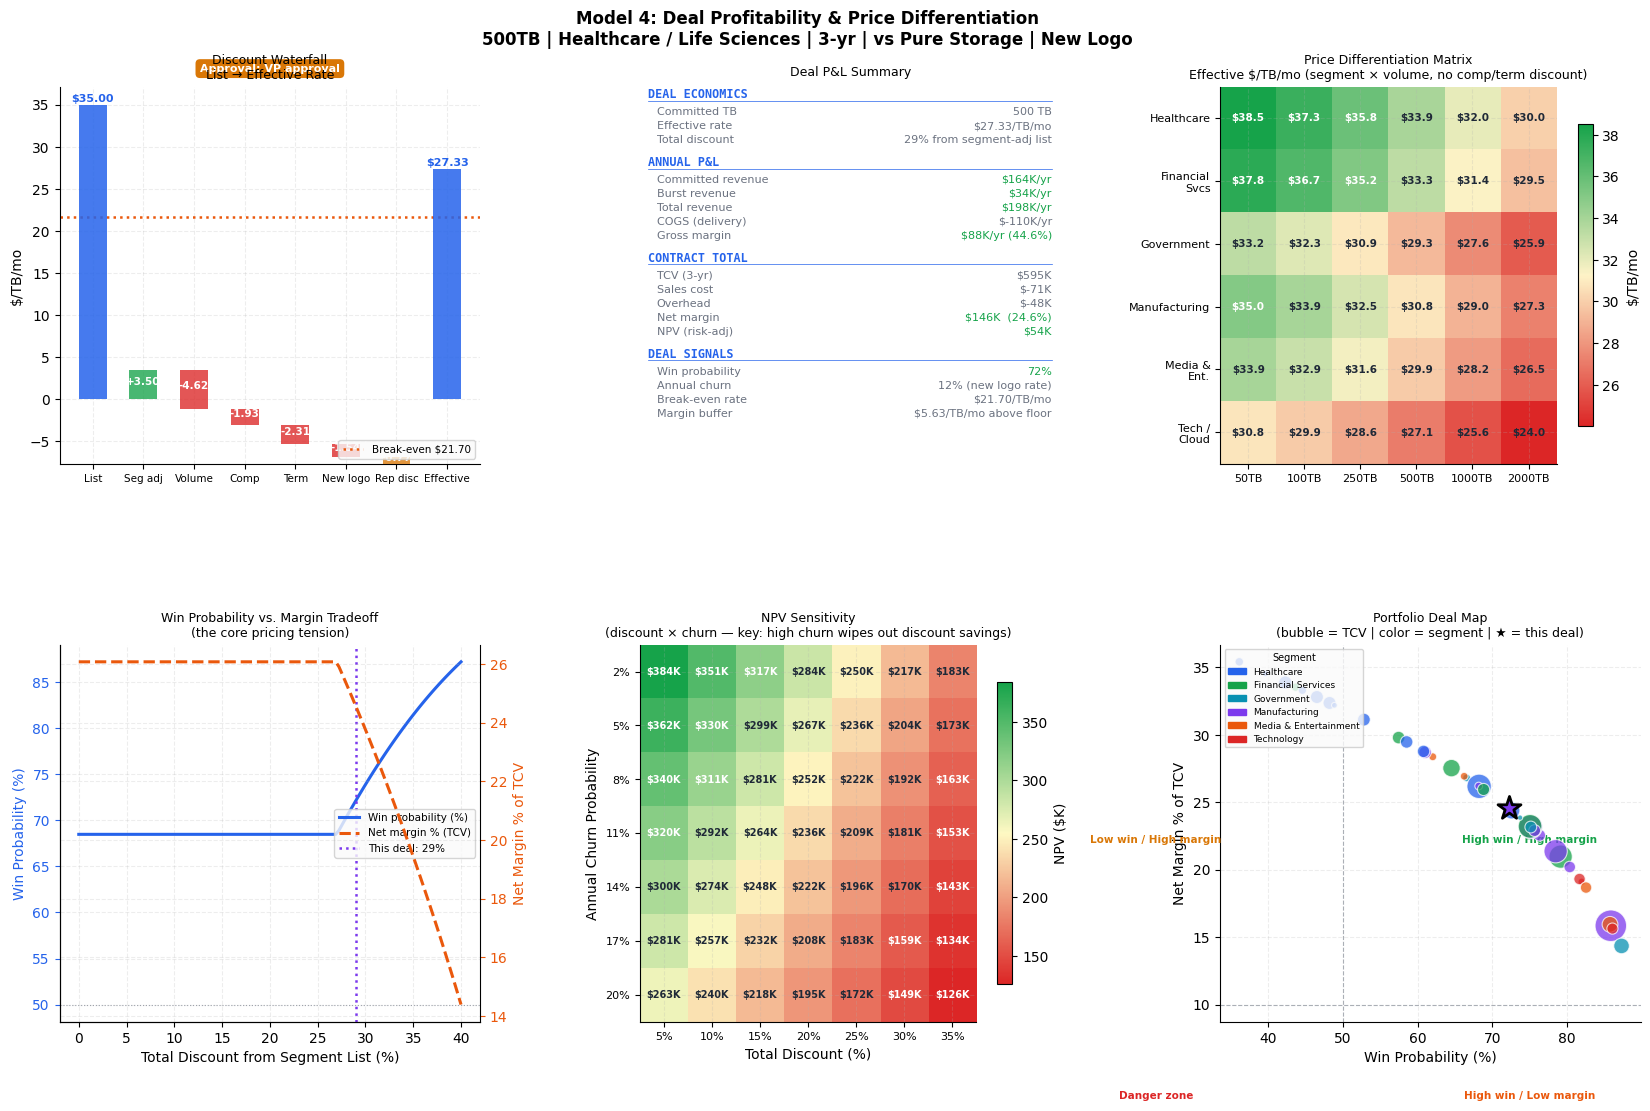

Model 4 complete.


In [5]:
fig = plt.figure(figsize=(17, 11))
fig.patch.set_facecolor('white')
fig.suptitle(
    f'Model 4: Deal Profitability & Price Differentiation\n'
    f'{deal["committed_tb"]}TB | {deal["segment"]} | {deal["contract_years"]}-yr | '
    f'vs {deal["competitor"]} | New Logo',
    fontsize=12, fontweight='bold', y=0.99
)
gs = gridspec.GridSpec(2, 3, hspace=0.48, wspace=0.38,
                       left=0.06, right=0.99, top=0.92, bottom=0.07)

# ─── Panel 1: Discount Waterfall ────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.set_facecolor('white')

steps = [
    ('List',        deal['list_rate'],                                         BLUE),
    ('Seg adj',     deal['seg_adj_list'] - deal['list_rate'],                  GREEN),
    ('Volume',     -deal['vol_disc']  * deal['seg_adj_list'],                  RED),
    ('Comp',       -deal['comp_disc'] * deal['seg_adj_list'],                  RED),
    ('Term',       -deal['term_disc'] * deal['seg_adj_list'],                  RED),
    ('New logo',   -deal['logo_disc'] * deal['seg_adj_list'],                  RED),
    ('Rep disc',   -deal['rep_disc']  * deal['seg_adj_list'],                  AMBER),
    ('Effective',   deal['effective_rate'],                                     BLUE),
]

running = 0
for i, (lbl, val, col) in enumerate(steps):
    if lbl in ('List', 'Effective'):
        ax1.bar(i, val, color=col, alpha=0.85, width=0.55, zorder=3)
        ax1.text(i, val + 0.4, f'${val:.2f}', ha='center',
                 fontsize=8, fontweight='bold', color=col)
    else:
        ax1.bar(i, abs(val), bottom=min(running, running + val),
                color=col, alpha=0.78, width=0.55, zorder=3)
        ax1.text(i, running + val / 2, f'{val:+.2f}', ha='center',
                 fontsize=7.5, color='white', fontweight='bold')
    if lbl not in ('List', 'Effective'):
        running += val

ax1.axhline(deal['breakeven_rate'], color=ORANGE, lw=1.8, linestyle=':',
            label=f'Break-even ${deal["breakeven_rate"]:.2f}')
ax1.set_xticks(range(len(steps)))
ax1.set_xticklabels([s[0] for s in steps], fontsize=7.5)
ax1.set_ylabel('$/TB/mo')
ax1.set_title('Discount Waterfall\nList → Effective Rate', fontsize=9)
ax1.legend(fontsize=7.5, loc='lower right')

auth_col = {'Rep (no approval)':GREEN,'Manager approval':TEAL,
            'Deal desk':BLUE,'VP approval':AMBER,'Executive (SVP+)':RED}
ax1.text(0.5, 1.04, f'Approval: {deal["approval_tier"]}',
         transform=ax1.transAxes, ha='center', fontsize=8, fontweight='bold',
         color='white', bbox=dict(boxstyle='round,pad=0.4',
         facecolor=auth_col.get(deal['approval_tier'], GRAY), edgecolor='none'))

# ─── Panel 2: P&L Text Summary ──────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
ax2.set_facecolor('white'); ax2.axis('off')

rows = [
    ('DEAL ECONOMICS', None, True),
    ('Committed TB',       f'{deal["committed_tb"]} TB',                                 False),
    ('Effective rate',     f'${deal["effective_rate"]:.2f}/TB/mo',                       False),
    ('Total discount',     f'{deal["total_disc"]*100:.0f}% from segment-adj list',       False),
    ('', '', False),
    ('ANNUAL P&L', None, True),
    ('Committed revenue',  fmt_k(deal['committed_rev_yr'])  + '/yr',                     False),
    ('Burst revenue',      fmt_k(deal['burst_rev_yr'])      + '/yr',                     False),
    ('Total revenue',      fmt_k(deal['total_rev_yr'])      + '/yr',                     False),
    ('COGS (delivery)',    fmt_k(-deal['cogs_yr'])           + '/yr',                     False),
    ('Gross margin',       f'{fmt_k(deal["gross_margin_yr"])}/yr ({deal["gross_margin_pct"]*100:.1f}%)', False),
    ('', '', False),
    ('CONTRACT TOTAL', None, True),
    ('TCV (3-yr)',          fmt_k(deal['total_tcv']),                                     False),
    ('Sales cost',          fmt_k(-deal['sales_cost']),                                   False),
    ('Overhead',            fmt_k(-deal['overhead']),                                     False),
    ('Net margin',         f'{fmt_k(deal["net_margin_tcv"])}  ({deal["net_margin_pct"]*100:.1f}%)', False),
    ('NPV (risk-adj)',      fmt_k(deal['npv_net']),                                       False),
    ('', '', False),
    ('DEAL SIGNALS', None, True),
    ('Win probability',     f'{deal["win_prob"]*100:.0f}%',                              False),
    ('Annual churn',        f'{deal["churn_annual"]*100:.0f}% (new logo rate)',           False),
    ('Break-even rate',     f'${deal["breakeven_rate"]:.2f}/TB/mo',                      False),
    ('Margin buffer',       f'${deal["effective_rate"]-deal["breakeven_rate"]:.2f}/TB/mo above floor', False),
]

y = 0.97
for lbl, val, hdr in rows:
    if lbl == '': y -= 0.024; continue
    if hdr:
        ax2.text(0.02, y, lbl, transform=ax2.transAxes,
                 fontsize=8.5, fontweight='bold', color=BLUE, fontfamily='monospace')
        ax2.plot([0.02, 0.98], [y-0.007, y-0.007], color=BLUE, lw=0.5,
                 transform=ax2.transAxes, clip_on=False)
        y -= 0.045
    else:
        ax2.text(0.04, y, lbl, transform=ax2.transAxes, fontsize=8, color=GRAY)
        c = RED if val and val.startswith('-') else \
            (GREEN if val and any(x in lbl for x in ['margin','NPV','Win','revenue']) else GRAY)
        ax2.text(0.98, y, str(val), transform=ax2.transAxes,
                 fontsize=8, color=c, ha='right', fontweight='500')
        y -= 0.037
ax2.set_title('Deal P&L Summary', fontsize=9, pad=8)

# ─── Panel 3: Price Differentiation Matrix ──────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
ax3.set_facecolor('white')

segs      = list(SEG_MULT.keys())
tb_tiers  = [50, 100, 250, 500, 1000, 2000]
short_seg = ['Healthcare','Financial\nSvcs','Government','Manufacturing','Media &\nEnt.','Tech /\nCloud']
rm = np.array([[LIST_RATE * SEG_MULT[s] * (1 - get_vol_disc(tb))
                for tb in tb_tiers] for s in segs])

cmap3 = LinearSegmentedColormap.from_list('rg', ['#DC2626','#FEF3C7','#16A34A'], N=256)
im = ax3.imshow(rm, aspect='auto', cmap=cmap3, vmin=rm.min(), vmax=rm.max())
for i in range(len(segs)):
    for j in range(len(tb_tiers)):
        v = rm[i, j]
        tc = 'white' if (v < 22 or v > 34) else '#1f2937'
        ax3.text(j, i, f'${v:.1f}', ha='center', va='center',
                 fontsize=7.5, color=tc, fontweight='bold')
ax3.set_xticks(range(len(tb_tiers)))
ax3.set_xticklabels([f'{t}TB' for t in tb_tiers], fontsize=8)
ax3.set_yticks(range(len(segs)))
ax3.set_yticklabels(short_seg, fontsize=8)
ax3.set_title('Price Differentiation Matrix\nEffective $/TB/mo (segment × volume, no comp/term discount)', fontsize=9)
plt.colorbar(im, ax=ax3, label='$/TB/mo', shrink=0.8)

# ─── Panel 4: Win Probability vs. Margin Tradeoff ───────────────────
ax4 = fig.add_subplot(gs[1, 0])
ax4.set_facecolor('white')

discs = np.linspace(0, 0.40, 120)
wps, nms = [], []
for disc in discs:
    extra = max(0, disc - deal['vol_disc'] - deal['comp_disc']
                - deal['term_disc'] - deal['logo_disc'])
    d = compute_deal(deal['committed_tb'], deal['segment'], deal['contract_years'],
                     deal['competitor'], deal['is_new_logo'], rep_disc=extra)
    wps.append(d['win_prob'] * 100)
    nms.append(d['net_margin_pct'] * 100)

ax4t = ax4.twinx()
l1, = ax4.plot(discs*100, wps, color=BLUE, lw=2.2, label='Win probability (%)')
l2, = ax4t.plot(discs*100, nms, color=ORANGE, lw=2.2, linestyle='--', label='Net margin % (TCV)')
ax4.axvline(deal['total_disc']*100, color=PURPLE, lw=1.8, linestyle=':',
            label=f'This deal: {deal["total_disc"]*100:.0f}%')
ax4.axhline(50, color=GRAY, lw=0.8, linestyle=':', alpha=0.6)
ax4.set_xlabel('Total Discount from Segment List (%)')
ax4.set_ylabel('Win Probability (%)', color=BLUE)
ax4t.set_ylabel('Net Margin % of TCV', color=ORANGE)
ax4.tick_params(axis='y', colors=BLUE)
ax4t.tick_params(axis='y', colors=ORANGE)
ax4t.spines['right'].set_visible(True)
ax4t.spines['top'].set_visible(False)
ax4.set_title('Win Probability vs. Margin Tradeoff\n(the core pricing tension)', fontsize=9)
ax4.legend(handles=[
    l1, l2,
    plt.Line2D([0],[0], color=PURPLE, lw=1.8, linestyle=':',
               label=f'This deal: {deal["total_disc"]*100:.0f}%')
], fontsize=7.5, loc='center right')

# ─── Panel 5: NPV Sensitivity Grid (discount x churn) ───────────────
ax5 = fig.add_subplot(gs[1, 1])
ax5.set_facecolor('white')

dr = np.linspace(0.05, 0.35, 7)
cr = np.linspace(0.02, 0.20, 7)
npv_g = np.zeros((len(cr), len(dr)))
for i, churn in enumerate(cr):
    for j, disc in enumerate(dr):
        r  = LIST_RATE * SEG_MULT[deal['segment']] * (1 - disc)
        br = r * (1 + BURST_PREM)
        ry = deal['committed_tb'] * (r + AVG_BURST * br) * 12
        cy = deal['committed_tb'] * (COGS_PER_TB + SUPPORT_PER_TB) * 12
        sp = [(1 - churn)**yr for yr in range(1, deal['contract_years'] + 1)]
        npv_g[i, j] = sum((ry - cy) * s / (1 + WACC)**yr
                          for yr, s in enumerate(sp, 1)) / 1_000

cmap5 = LinearSegmentedColormap.from_list('rg', ['#DC2626','#FEF9C3','#16A34A'], N=256)
im2 = ax5.imshow(npv_g, aspect='auto', cmap=cmap5, vmin=npv_g.min(), vmax=npv_g.max())
for i in range(len(cr)):
    for j in range(len(dr)):
        v = npv_g[i, j]
        tc = 'white' if v < npv_g.mean() * 0.7 or v > npv_g.mean() * 1.3 else '#1f2937'
        ax5.text(j, i, f'${v:.0f}K', ha='center', va='center',
                 fontsize=7, color=tc, fontweight='bold')
ax5.set_xticks(range(len(dr)))
ax5.set_xticklabels([f'{d*100:.0f}%' for d in dr], fontsize=8)
ax5.set_yticks(range(len(cr)))
ax5.set_yticklabels([f'{c*100:.0f}%' for c in cr], fontsize=8)
ax5.set_xlabel('Total Discount (%)')
ax5.set_ylabel('Annual Churn Probability')
ax5.set_title('NPV Sensitivity\n(discount × churn — key: high churn wipes out discount savings)', fontsize=9)
plt.colorbar(im2, ax=ax5, label='NPV ($K)', shrink=0.8)

# ─── Panel 6: Portfolio Map ─────────────────────────────────────────
ax6 = fig.add_subplot(gs[1, 2])
ax6.set_facecolor('white')

np.random.seed(7)
n_d = 40
p_segs  = np.random.choice(list(SEG_MULT.keys()), n_d)
p_tbs   = np.random.choice([50,100,250,500,1000,2000], n_d, p=[0.15,0.25,0.28,0.18,0.10,0.04])
p_comps = np.random.choice(list(COMP_DISC.keys()), n_d, p=[0.35,0.25,0.18,0.10,0.12])
p_new   = np.random.choice([True, False], n_d, p=[0.4, 0.6])
p_rd    = np.random.uniform(0, 0.08, n_d)
pw, pm, pt, ps = [], [], [], []
for i in range(n_d):
    pd2 = compute_deal(int(p_tbs[i]), p_segs[i], 3, p_comps[i],
                       bool(p_new[i]), rep_disc=float(p_rd[i]))
    pw.append(pd2['win_prob']*100)
    pm.append(pd2['net_margin_pct']*100)
    pt.append(pd2['total_tcv']/1_000)
    ps.append(p_segs[i])

sc_cols = {
    'Healthcare / Life Sciences': BLUE,  'Financial Services': GREEN,
    'Government / Federal': TEAL,        'Manufacturing / Industrial': PURPLE,
    'Media & Entertainment': ORANGE,     'Technology / Cloud-Native': RED,
}
pc = [sc_cols[s] for s in ps]
ax6.scatter(pw, pm, s=[t/4 for t in pt], c=pc, alpha=0.75,
            edgecolors='white', lw=0.8, zorder=4)
ax6.scatter(deal['win_prob']*100, deal['net_margin_pct']*100,
            s=300, c=PURPLE, edgecolors='black', lw=2,
            zorder=6, marker='*', label='This deal')
ax6.axvline(50, color=GRAY, lw=0.8, linestyle='--', alpha=0.5)
ax6.axhline(10, color=GRAY, lw=0.8, linestyle='--', alpha=0.5)
for txt, xp, yp, col in [
    ('High win / High margin', 75, 22, GREEN),
    ('Low win / High margin',  25, 22, AMBER),
    ('High win / Low margin',  75,  3, ORANGE),
    ('Danger zone',            25,  3, RED),
]:
    ax6.text(xp, yp, txt, fontsize=7.5, color=col, fontweight='bold', ha='center')
ax6.set_xlabel('Win Probability (%)')
ax6.set_ylabel('Net Margin % of TCV')
ax6.set_title('Portfolio Deal Map\n(bubble = TCV | color = segment | ★ = this deal)', fontsize=9)
lp = [mpatches.Patch(color=c, label=s.split('/')[0].strip()) for s, c in sc_cols.items()]
ax6.legend(handles=lp, fontsize=6.5, loc='upper left', title='Segment', title_fontsize=7)

plt.savefig('model4_deal_profitability.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('Model 4 complete.')

## Scenario Comparison — Try Different Deals

In [6]:
# Change any parameter and re-run to see deal economics shift
scenarios = [
    dict(name='Healthcare 500TB | Pure | 3-yr | new logo',
         committed_tb=500, segment='Healthcare / Life Sciences',
         contract_years=3, competitor='Pure Storage',
         is_new_logo=True, rep_disc=0.02),
    dict(name='Tech 100TB | AWS | 1-yr | new logo',
         committed_tb=100, segment='Technology / Cloud-Native',
         contract_years=1, competitor='Hyperscaler (AWS/Azure/GCP)',
         is_new_logo=True, rep_disc=0.04),
    dict(name='FinServ 1000TB | no competitor | 5-yr | existing',
         committed_tb=1000, segment='Financial Services',
         contract_years=5, competitor='None',
         is_new_logo=False, rep_disc=0.00),
    dict(name='Government 250TB | HPE | 3-yr | new logo',
         committed_tb=250, segment='Government / Federal',
         contract_years=3, competitor='HPE GreenLake',
         is_new_logo=True, rep_disc=0.03),
    dict(name='Manufacturing 500TB | no competitor | 3-yr | existing',
         committed_tb=500, segment='Manufacturing / Industrial',
         contract_years=3, competitor='None',
         is_new_logo=False, rep_disc=0.00),
]

print(f'{"Scenario":<48} {"Rate":>7} {"Disc%":>6} {"GM%":>6} {"NM%":>6} {"NPV":>9} {"Win%":>6}  Approval')
print('─'*120)
for s in scenarios:
    name = s.pop('name')
    d = compute_deal(**s)
    print(f'{name:<48} '
          f'${d["effective_rate"]:>5.2f}  '
          f'{d["total_disc"]*100:>5.1f}%  '
          f'{d["gross_margin_pct"]*100:>5.1f}%  '
          f'{d["net_margin_pct"]*100:>5.1f}%  '
          f'{fmt_k(d["npv_net"]):>9}  '
          f'{d["win_prob"]*100:>5.0f}%  '
          f'{d["approval_tier"]}')

Scenario                                            Rate  Disc%    GM%    NM%       NPV   Win%  Approval
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Healthcare 500TB | Pure | 3-yr | new logo        $27.33   29.0%   44.6%   24.6%       $54K     72%  VP approval
Tech 100TB | AWS | 1-yr | new logo               $25.56   17.0%   40.7%   20.7%        $5K     80%  Manager approval
FinServ 1000TB | no competitor | 5-yr | existing $27.59   27.0%   45.1%   25.1%      $194K     71%  VP approval
Government 250TB | HPE | 3-yr | new logo         $25.27   24.0%   40.0%   20.0%       $17K     81%  Deal desk
Manufacturing 500TB | no competitor | 3-yr | existing $28.70   18.0%   47.2%   27.2%       $97K     65%  Manager approval
